## Setup and Imports

In [1]:
!pip install ultralytics pinecone transformers accelerate ftfy regex tqdm -q
!pip install git+https://github.com/openai/CLIP.git -q

import os
import gc
import math
import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import clip

from huggingface_hub import hf_hub_download
from PIL import Image
from dotenv import load_dotenv
from ultralytics import YOLO
from pinecone import Pinecone
from transformers import (
    Blip2Processor,
    Blip2ForConditionalGeneration
)
print("Done.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 94.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 19.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Done.


## Load Dataset

In [2]:
gc.collect()
torch.cuda.empty_cache()

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DATASET_ROOT = "/kaggle/input/datasets/dedeepyaavancha/deepfashion-in-shop-clothes-retrieval-benchmark/In-shop Clothes Retrieval Benchmark"

TOP_K = 15
ALPHA = 0.7

MAX_QUERY_IMAGES = 100

print(f"\nUsing device: {DEVICE}")

# LOAD SPLITS

print("\nLoading DeepFashion splits...")

eval_path = os.path.join(
    DATASET_ROOT,
    "Eval",
    "list_eval_partition.txt"
)

df = pd.read_csv(
    eval_path,
    sep=r"\s+",
    skiprows=2,
    header=None,
    names=["image_name", "item_id", "split"]
)

df_query = df[
    df["split"] == "query"
].reset_index(drop=True)

df_gallery = df[
    df["split"] == "gallery"
].reset_index(drop=True)

if MAX_QUERY_IMAGES is not None:

    df_query = df_query.sample(
        n=min(MAX_QUERY_IMAGES, len(df_query)),
        random_state=42
    ).reset_index(drop=True)

query_paths = [
    os.path.join(DATASET_ROOT, x)
    for x in df_query["image_name"].tolist()
]

query_item_ids = df_query[
    "item_id"
].astype(str).tolist()

gallery_item_lookup = {}

for _, row in df_gallery.iterrows():

    gallery_item_lookup[
        row["image_name"]
    ] = str(row["item_id"])

print(f"Query Images   : {len(query_paths)}")
print(f"Gallery Images : {len(df_gallery)}")





Using device: cuda

Loading DeepFashion splits...
Query Images   : 100
Gallery Images : 12612


## Load models and Connect to Pinecone

In [3]:

# LOAD YOLO ON CPU

print("\nLoading YOLO...")

yolo_model = YOLO("yolov8n.pt")
yolo_model.to("cpu")

print("YOLO loaded.")

gc.collect()
torch.cuda.empty_cache()

# LOAD CLIP


print("\nLoading CLIP...")

clip_model, preprocess = clip.load(
    "ViT-B/32",
    device=DEVICE,
    jit=False
)

checkpoint_path = hf_hub_download(
    repo_id="matt-terofact/vestique-clip",
    filename="clip.pt"
)

checkpoint = torch.load(
    checkpoint_path,
    map_location=DEVICE
)

clip_model.load_state_dict(
    checkpoint
)


clip_model.eval()

print("CLIP loaded.")

gc.collect()
torch.cuda.empty_cache()

# LOAD BLIP2 WITH DEVICE MAP

print("\nLoading BLIP2...")

blip_processor = Blip2Processor.from_pretrained(
    "Salesforce/blip2-opt-2.7b"
)

blip_model = Blip2ForConditionalGeneration.from_pretrained(
    "Salesforce/blip2-opt-2.7b",
    device_map="auto"
)

blip_model.eval()

print("BLIP2 loaded.")

gc.collect()
torch.cuda.empty_cache()

# LOAD PINECONE
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()

PINECONE_API_KEY = user_secrets.get_secret(
    "PINECONE_API_KEY"
)

print("\nConnecting to Pinecone...")

pc = Pinecone(
    api_key=PINECONE_API_KEY
)

index = pc.Index("visual-search-index")

print("Pinecone connected.")





Loading YOLO...
YOLO loaded.

Loading CLIP...


100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 351MiB/s]


clip.pt:   0%|          | 0.00/605M [00:00<?, ?B/s]

CLIP loaded.

Loading BLIP2...


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/accelerate/utils/modeling.py:1598: UserWarning: The following device_map keys do not match any submodules in the model: ['query_tokens']
  warnings.warn(


BLIP2 loaded.

Connecting to Pinecone...
Pinecone connected.


## Helper Functions

In [4]:
# HELPERS

def crop_main_object(image_path):

    image = Image.open(image_path).convert("RGB")

    results = yolo_model(image_path, verbose=False)

    boxes = results[0].boxes

    if len(boxes) == 0:
        return image

    largest_area = -1
    best_box = None

    for box in boxes:

        x1, y1, x2, y2 = box.xyxy[0].tolist()

        area = (x2 - x1) * (y2 - y1)

        if area > largest_area:

            largest_area = area
            best_box = (x1, y1, x2, y2)

    x1, y1, x2, y2 = map(int, best_box)

    cropped = image.crop((x1, y1, x2, y2))

    return cropped


def generate_caption(image):

    inputs = blip_processor(
        images=image,
        return_tensors="pt"
    ).to(DEVICE)

    with torch.no_grad():

        generated_ids = blip_model.generate(
            **inputs,
            max_new_tokens=25
        )

    caption = blip_processor.decode(
        generated_ids[0],
        skip_special_tokens=True
    )

    del inputs
    del generated_ids

    gc.collect()
    torch.cuda.empty_cache()

    return caption


def encode_image(image):

    image_input = preprocess(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():

        emb = clip_model.encode_image(image_input)

    emb = emb / emb.norm(
        dim=-1,
        keepdim=True
    )

    emb = emb.float().cpu().numpy()

    del image_input

    gc.collect()
    torch.cuda.empty_cache()

    return emb

def encode_text(text):

    tokens = clip.tokenize(
        [text],
        truncate=True
    ).to(DEVICE)

    with torch.no_grad():

        emb = clip_model.encode_text(tokens)

    emb = emb / emb.norm(
        dim=-1,
        keepdim=True
    )

    emb = emb.float().cpu().numpy()

    del tokens

    gc.collect()
    torch.cuda.empty_cache()

    return emb


def create_fused_embedding(image_path):

    cropped = crop_main_object(image_path)

    caption = generate_caption(cropped)

    image_emb = encode_image(cropped)

    text_emb = encode_text(caption)

    fused = (
        ALPHA * image_emb
        +
        (1 - ALPHA) * text_emb
    )

    fused = fused / np.linalg.norm(
        fused,
        axis=1,
        keepdims=True
    )

    return fused[0], caption, cropped


def retrieve(query_embedding):

    results = index.query(
        vector=query_embedding.tolist(),
        top_k=TOP_K,
        include_metadata=True
    )

    return results["matches"]



## Evalutation Metrics

In [5]:
def recall_at_k(relevant, k):

    return 1.0 if any(relevant[:k]) else 0.0


def ndcg_at_k(relevant, k):

    dcg = 0.0

    for idx, rel in enumerate(relevant[:k]):

        if rel:

            dcg += 1.0 / math.log2(idx + 2)

    total_rel = sum(relevant)

    idcg = 0.0

    for idx in range(min(total_rel, k)):

        idcg += 1.0 / math.log2(idx + 2)

    if idcg == 0:
        return 0.0

    return dcg / idcg


def average_precision_at_k(relevant, k):

    hits = 0
    precision_sum = 0.0

    for idx, rel in enumerate(relevant[:k]):

        if rel:

            hits += 1
            precision_sum += hits / (idx + 1)

    total_rel = sum(relevant)

    if total_rel == 0:
        return 0.0

    return precision_sum / min(total_rel, k)


## Evaluation

In [6]:
metrics = {
    5: {"Recall": [], "NDCG": [], "mAP": []},
    10: {"Recall": [], "NDCG": [], "mAP": []},
    15: {"Recall": [], "NDCG": [], "mAP": []}
}

RERANK_TOP_N = 25

print("\nRunning evaluation with BLIP2 reranking...")

for i, query_path in enumerate(query_paths):

    try:

        query_item_id = query_item_ids[i]

        query_embedding, caption, cropped = create_fused_embedding(
            query_path
        )

        matches = index.query(
            vector=query_embedding.tolist(),
            top_k=RERANK_TOP_N,
            include_metadata=True
        )["matches"]

        reranked_candidates = []

        for match in matches:

            metadata = match["metadata"]

            candidate_caption = metadata.get(
                "caption",
                ""
            )

            retrieved_rel_path = metadata["image_name"]

            inputs = blip_processor(
                images=cropped,
                text=candidate_caption,
                return_tensors="pt"
            ).to(DEVICE)

            with torch.no_grad():

                outputs = blip_model(
                    **inputs,
                    labels=inputs["input_ids"]
                )

            itm_score = -outputs.loss.item()

            reranked_candidates.append({
                "path": retrieved_rel_path,
                "score": itm_score
            })

            del inputs
            del outputs

            gc.collect()
            torch.cuda.empty_cache()

        reranked_candidates = sorted(
            reranked_candidates,
            key=lambda x: x["score"],
            reverse=True
        )

        relevant = []

        for item in reranked_candidates:

            retrieved_item_id = gallery_item_lookup.get(
                item["path"],
                None
            )

            relevant.append(
                retrieved_item_id == query_item_id
            )

        for K in [5, 10, 15]:

            metrics[K]["Recall"].append(
                recall_at_k(relevant, K)
            )

            metrics[K]["NDCG"].append(
                ndcg_at_k(relevant, K)
            )

            metrics[K]["mAP"].append(
                average_precision_at_k(relevant, K)
            )

        if (i + 1) % 10 == 0:

            print(f"Processed {i+1}/{len(query_paths)}")

        del query_embedding
        del cropped

        gc.collect()
        torch.cuda.empty_cache()

    except Exception as e:

        print(f"Error on query {i}: {e}")

        gc.collect()
        torch.cuda.empty_cache()


Running evaluation with BLIP2 reranking...


The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when us

Processed 10/100


The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when us

Processed 20/100


...

Processed 80/100


The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when us

Processed 90/100


The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when us

Processed 100/100


## Final Metrics

In [7]:
print("\n===== FINAL METRICS =====\n")

print(
    f"{'K':<5}"
    f"{'Recall':<12}"
    f"{'NDCG':<12}"
    f"{'mAP':<12}"
)

print("-" * 45)

for K in [5, 10, 15]:

    recall = np.mean(metrics[K]["Recall"])
    ndcg = np.mean(metrics[K]["NDCG"])
    mAP = np.mean(metrics[K]["mAP"])

    print(
        f"{K:<5}"
        f"{recall:<12.4f}"
        f"{ndcg:<12.4f}"
        f"{mAP:<12.4f}"
    )




===== FINAL METRICS =====

K    Recall      NDCG        mAP         
---------------------------------------------
5    0.3800      0.1905      0.1402      
10   0.6000      0.2503      0.1644      
15   0.7200      0.3102      0.1899      


## Sample  Visualization


Displaying retrieval examples...


The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.


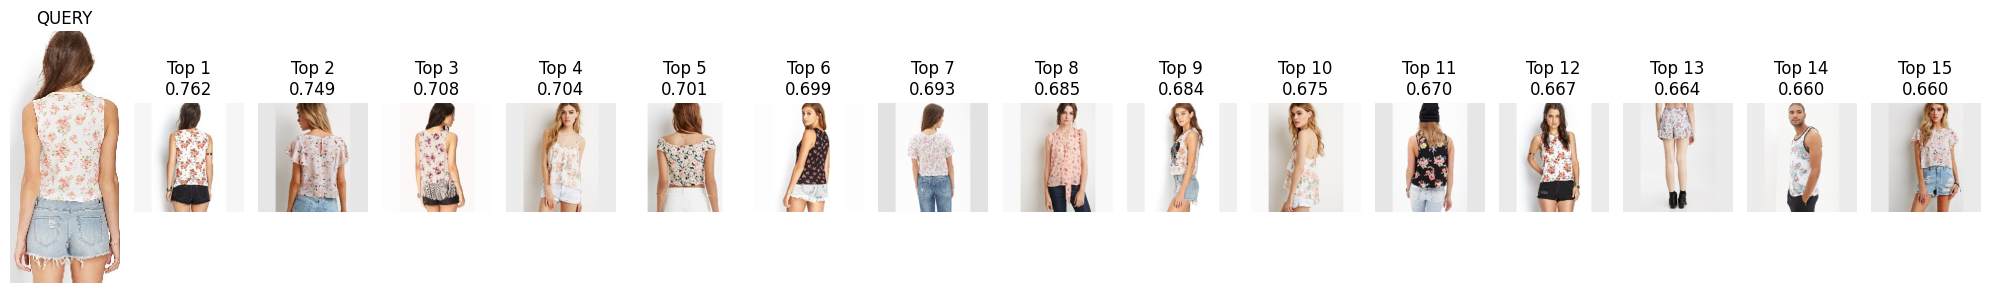

The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.


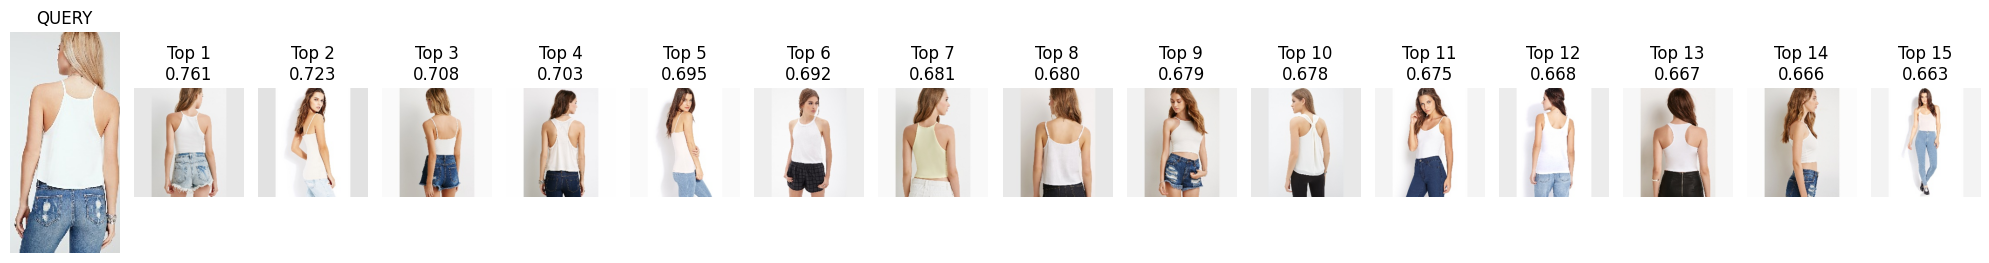

The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.


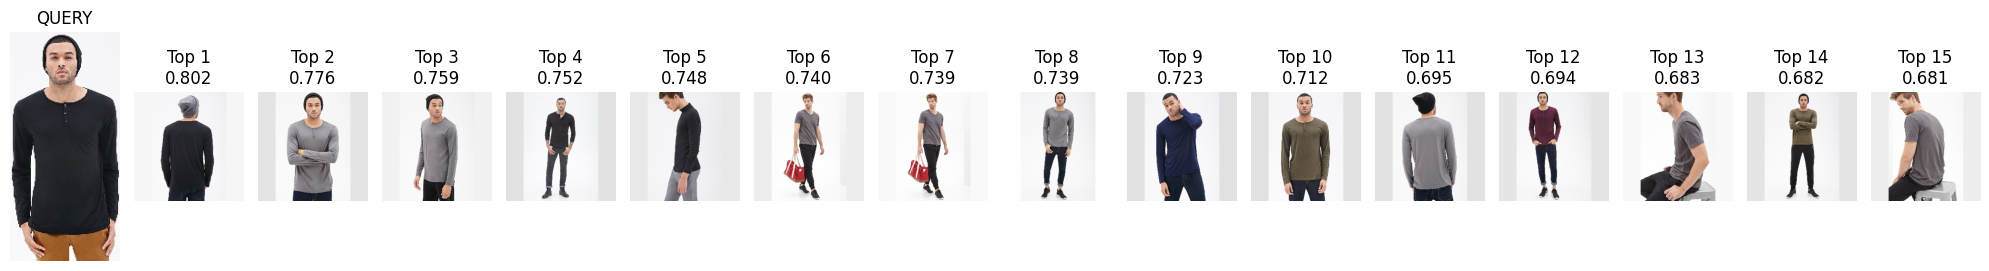


Done.


In [8]:
print("\nDisplaying retrieval examples...")

sample_indices = random.sample(
    range(len(query_paths)),
    min(3, len(query_paths))
)

for idx in sample_indices:

    query_path = query_paths[idx]

    query_embedding, caption, cropped = create_fused_embedding(
        query_path
    )

    matches = retrieve(query_embedding)

    fig, axes = plt.subplots(
        1,
        TOP_K + 1,
        figsize=(20, 5)
    )

    axes[0].imshow(cropped)
    axes[0].set_title("QUERY")
    axes[0].axis("off")

    for j, match in enumerate(matches):

        rel_path = match["metadata"]["image_name"]

        gallery_path = os.path.join(
            DATASET_ROOT,
            rel_path
        )

        score = match["score"]

        if os.path.exists(gallery_path):

            img = Image.open(
                gallery_path
            ).convert("RGB")

            axes[j + 1].imshow(img)

            axes[j + 1].set_title(
                f"Top {j+1}\n{score:.3f}"
            )

        axes[j + 1].axis("off")

    plt.tight_layout()
    plt.show()

    gc.collect()
    torch.cuda.empty_cache()

print("\nDone.")